In [52]:
import os
import sys
cwd = os.getcwd()
new_cwd = '/'.join(cwd.split('\\')[:2])

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.parse import ChartParser, ViterbiParser
from nltk.grammar import CFG, PCFG, Nonterminal, ProbabilisticProduction
from nltk.tree import Tree
import contractions
import string
from collections import defaultdict
import spacy

nlp = spacy.load("en_core_web_sm")

import json

with open(f"{new_cwd}/data/en_vi_dictionary.json", "r", encoding='utf-8') as json_file:
    dictionary = json.load(json_file)

with open(f'{new_cwd}/grammar.txt', 'r', encoding='utf-8') as text_file:
    grammar = text_file.read()


class TransferBasedMT:

    def __init__(self) -> None:
        # English - Vietnamese dictionary
        self.dictionary = dictionary

        # Define the CFG grammar for English sentence structure
        self.grammar = grammar
        

################################################ STAGE 1: PREPROCESSING SOURCE SENTENCE ###################################################

    def preprocessing(self, sentence: str) -> str:
        """Preprocess the input sentence: handle named entities, lowercase, expand contractions, and tokenize and regroup."""
        # Handle named entities, e.g. New York -> New_York
        doc = nlp(sentence)
        entities = {ent.text: ent.label_ for ent in doc.ents}
        for ent_text in sorted(entities.keys(), key=len,reverse=True):
            ent_joined = ent_text.replace(" ", "_")
            sentence = sentence.replace(ent_text, ent_joined)
            
        # Lowercase and strip redundant space
        sentence = sentence.lower().strip()
        
        # Expand contractions, e.g. don't -> do not 
        sentence = contractions.fix(sentence)   #type: ignore
        
        # Tokenize and regroup tokens
        sentence = " ".join(word_tokenize(sentence))
        
        return sentence
    
    
    def safe_tag(self, tag):
        """Convert tags with special characters to safe nonterminal symbols."""
        return tag.replace("$", "S")


################################################ STAGE 2: ANALYZE SOURCE SENTENCE #########################################################

    def analyze_source(self, sentence: str):
        """Analyze the source sentence: tokenize, POS tag, and parse into a syntax tree."""
        doc = nlp(sentence)
        filtered_pos_tagged = []  
        punctuation_marks = []
        
        for i, token in enumerate(doc):
            word = token.text
            tag = token.tag_
            if all(char in string.punctuation for char in word):
                punctuation_marks.append((i, word, tag))
            else:
                filtered_pos_tagged.append((token.lemma_.lower(), tag))
                
        grammar_str = self.grammar
        
        # Add terminal rule grammars
        for word, tag in filtered_pos_tagged:
            safe_tag = self.safe_tag(tag)
            escaped_word = word.replace('"', '\\"') 
            grammar_str += f'\n{safe_tag} -> "{escaped_word}"'
            
        try:
            grammar = CFG.fromstring(grammar_str)
            parser = ChartParser(grammar)
            tagged_tokens_only = [word for word, _ in filtered_pos_tagged]
            
            parses = list(parser.parse(tagged_tokens_only))  # Generate parse trees
            
            tree = (parses[0] if parses else self._create_fallback_tree(filtered_pos_tagged))  # Use first parse or fallback
            tree = self._add_punctuation_to_tree(tree, punctuation_marks)  # Reattach punctuation
            
            return tree
        
        except Exception as e:
            print(f"Grammar creation error: {e}")
            return self._create_fallback_tree(filtered_pos_tagged)  # Fallback on error


    def _create_fallback_tree(self, pos_tagged):
        """Create a simple fallback tree when parsing fails."""
        children = [Tree(self.safe_tag(tag), [word]) for word, tag in pos_tagged]  # Create leaf nodes for each token
        return Tree("S", children)  # Wrap in a sentence node


    def _add_punctuation_to_tree(self, tree, punctuation_marks):
        """Add punctuation marks back to the syntax tree."""
        if not punctuation_marks:
            return tree
        if tree.label() == "S":  # Only add to root sentence node
            for _, word, tag in sorted(punctuation_marks): 
                tree.append(Tree(self.safe_tag(tag), [word]))
        return tree


#################################################### STAGE 3: TRANSFER GRAMMAR ############################################################

    def transfer_grammar(self, tree):
        """Transfer the English parse tree to Vietnamese structure."""
        if not isinstance(tree, nltk.Tree):
            return tree 
        
        # Sentence level: recurse through children
        if tree.label() == "S":
            return Tree("S", [self.transfer_grammar(child) for child in tree])
        
        # Verb Phrase: adjust word order
        elif tree.label() == "VP":
            children = [self.transfer_grammar(child) for child in tree]
            child_labels = [child.label() if isinstance(child, Tree) else child for child in children]
            
            if (len(children) >= 3 and "V" in child_labels and "To" in child_labels and "VP" in child_labels):  # Remove TO from V TO VP
                return Tree("VP", [children[0], children[2]]) 
            
            return Tree("VP", children)  # Default: preserve order
        
        # Noun Phrase: adjust word order
        elif tree.label() == "NP":
            children = [self.transfer_grammar(child) for child in tree]
            child_labels = [child.label() if isinstance(child, Tree) else child for child in children]
            
            if (len(children) >= 3 and 'Det' in child_labels and 'AdjP' in child_labels and 'N' in child_labels): # Reorder Det Adj N -> Det N Adj
                return Tree("NP", [children[0], children[2], children[1]])
            
            elif (len(children) >= 2 and 'PRPS' in child_labels and 'N' in child_labels):  # Reorder PRPS N -> N PRPS
                return Tree("NP", [children[1], children[0]])
            
            elif (len(children) >= 2 and 'Det' in child_labels and 'N' in child_labels):   # Remove Det from Det N
                return Tree("NP", [children[1]])
            
            return Tree("NP", children)  # Default: preserve order
        
        # Prepositional Phrase: adjust word order
        elif tree.label() == "PP":
            children = [self.transfer_grammar(child) for child in tree]
            return Tree("PP", children)  # Default: preserve order
        
        # Adverbial Phrase: adjust word order 
        elif tree.label() == 'AdvP':
            children = [self.transfer_grammar(child) for child in tree]
            return Tree("AdvP", children)  # Default: preserve order
        
        # Adjective Phrase: adjust word order 
        elif tree.label() == 'AdjP':
            children = [self.transfer_grammar(child) for child in tree]
            return Tree("AdjP", children)  # Default: preserve order
        
        # Wh-Question: adjust word order 
        elif tree.label() == "WhQ":
            children = [self.transfer_grammar(child) for child in tree]
            child_labels = [child.label() if isinstance(child, Tree) else child for child in children] 
            
            if len(children) >= 4 and "WH_Word" in child_labels and "AUX" in child_labels and "NP" in child_labels and "VP" in child_labels:
                return Tree("WhQ", [children[2], children[3], children[0]])  # Remove AUX from  WH_Word AUX NP VP            
            
            elif len(children) >= 3 and "WH_Word" in child_labels and "NP" in child_labels and "VP" in child_labels and "AUX" not in child_labels:
                return Tree("WhQ", [children[1], children[2], children[0]])
            
            elif len(children) >= 2 and "WH_Word" in child_labels and "VP" in child_labels:
                if len(children[1]) >= 2:
                    return Tree("WhQ", [children[1][1], children[1][0], children[0]])  # WH_Word VP -> WH_Word V NP

            else:
                return Tree("WhQ", children)  # Default: preserve order
            
        # Yes/No-Question: adjust word order 
        elif tree.label() == "YNQ":
            children = [self.transfer_grammar(child) for child in tree]
            child_labels = [child.label() if isinstance(child, Tree) else child for child in children] 
            
            if len(children) >= 3 and "AUX" in child_labels and "NP" in child_labels and "VP" in child_labels:
                return Tree("YNQ", [children[1], children[2]])
            
            elif len(children) >= 3 and "DO" in child_labels and "NP" in child_labels and "VP" in child_labels:
                return Tree("YNQ", [children[1], children[2]])
            
            elif len(children) >= 3 and "MD" in child_labels and "NP" in child_labels and "VP" in child_labels:
                return Tree("YNQ", [children[1], children[2]])
            
            return Tree("YNQ", children)
            
        
        # Other labels: recurse through children
        else:
            return Tree(tree.label(), [self.transfer_grammar(child) for child in tree])


#################################################### STAGE 4: GENERATION STAGE ############################################################

    def generate(self, tree):
        """Generate Vietnamese output from the transformed tree."""
        if not isinstance(tree, nltk.Tree):
            return self._lexical_transfer(tree)  # Translate leaf nodes
            
        words = [self.generate(child) for child in tree if self.generate(child)]  # Recurse
        
        # Handle questions specifically
        if tree.label() == "WhQ":
            words = self._process_wh_question(tree, words)
        elif tree.label() == "YNQ":
            words = self._process_yn_question(tree, words)
        elif tree.label() == "NP":  # Add classifiers for nouns
            words = self._add_classifiers(tree, words)
        elif tree.label() == "VP":  # Apply tense/aspect/mood markers
            words = self._apply_tam_mapping(tree, words)
            
        words = self._apply_agreement(tree, words)  # Handle agreement (e.g., plurals)
        result = " ".join(words)  # Join words into a string
        
        return result


    def _process_wh_question(self, tree, words):
        """Process a Wh-question structure for Vietnamese."""
        # In Vietnamese, we often add question particles at the end
        # and sometimes move the question word to the end for some questions
        
        # First, filter out empty strings
        words = [w for w in words if w]
        
        # Get the question word if present
        wh_word = None
        for word in words:
            if word in ["cái gì", "ai", "ở đâu", "khi nào", "tại sao", "như thế nào", "cái nào", "của ai"]:
                wh_word = word
                break
        
        # Some Vietnamese questions might need restructuring
        if wh_word == "tại sao":  # "why" questions
            # Move "tại sao" to the beginning if not already there
            if words and words[0] != "tại sao":
                words.remove("tại sao")
                words.insert(0, "tại sao")
        elif wh_word == "như thế nào":  # "how" questions
            # For "how" questions, sometimes add question particle "vậy" at the end
            if "vậy" not in words:
                words.append("vậy")
        
        # Add appropriate final particle for questions that need it
        question_particles = ["vậy", "thế", "à", "hả"]
        has_particle = any(particle in words for particle in question_particles)
        
        if not has_particle and wh_word != "tại sao":  # "why" questions don't usually need final particles
            words.append("vậy")
            
        return words


    def _process_yn_question(self, tree, words):
        """Process a Yes/No question structure for Vietnamese."""
        # In Vietnamese, yes/no questions often use a structure like:
        # [statement] + question particle
        # or [statement] + không/phải không
        
        # Filter out auxiliary verbs not needed in Vietnamese
        words = [w for w in words if w not in ["", "do_vn", "does_vn", "did_vn"]]
        
        # Check if we already have a question particle - also check for _vn suffix versions
        has_question_particle = any(w in ["không", "à", "hả", "nhỉ", "chứ"] or 
                                   w in ["không_vn", "à_vn", "hả_vn", "nhỉ_vn", "chứ_vn"] 
                                   for w in words)
        
        # If no question particle, add "không" (most common yes/no question structure)
        if not has_question_particle:
            # If it appears to be a question about the past (has "đã"), 
            # use "phải không" instead of just "không"
            if "đã" in words or "đã_vn" in words:
                words.append("phải không")
            else:
                words.append("không")
                
        return words


    def _lexical_transfer(self, word):
        """Translate English words to Vietnamese using the dictionary."""
        if word in self.dictionary:
            return self.dictionary[word]  # Return translation if in dictionary
        return f"{word}_vn"  # Mark untranslated words with _vn suffix


    def _add_classifiers(self, np_tree, words):
        """Add Vietnamese classifiers based on nouns."""
        # noun_indices = [
        #     i for i, child in enumerate(np_tree) if isinstance(child, Tree)
        #     and child.label() in ["N", "NN", "NNS", "NNP", "NNPS"]
        # ]  # Find noun positions
        # for i in noun_indices:
        #     if len(words) > i and not any(words[i].startswith(prefix) for prefix in ["một_vn", "những_vn", "các_vn"]):  # Check if classifier is needed
        #         if words[i].endswith("_vn"):  # Add default classifier for untranslated nouns
        #             words.insert(i, "cái_vn")
        return words


    def _apply_tam_mapping(self, vp_tree, words):
        """Apply Vietnamese TAM (Tense, Aspect, Mood) markers to the word list.
        
        Args:
            vp_tree: A parse tree node representing the verb phrase.
            words: List of words to be modified with TAM markers.
        
        Returns:
            List of words with appropriate Vietnamese TAM markers inserted.
        """
        verb_tense = None
        mood = None

        # Identify verb tense and mood from the verb phrase tree
        for child in vp_tree:
            if isinstance(child, Tree):
                # Check for verb tense
                if child.label() in ["V", "VB", "VBD", "VBG", "VBN", "VBP", "VBZ"]:
                    verb_tense = child.label()
                # Check for mood indicators (e.g., modal verbs or subjunctive forms)
                if child.label() == "MD":  # Modal verbs indicating mood
                    mood = "indicative"
                elif child.label() == "TO":  # Infinitive marker, often subjunctive
                    mood = "subjunctive"

        # If no verb tense is found, return the original words with a warning
        if not verb_tense:
            print("Warning: No verb tense identified in the verb phrase tree.")
            return words

        # Apply TAM markers based on verb tense
        if verb_tense == "VBD":  # Past tense
            words.insert(0, "đã_vn")  # Past marker
        elif verb_tense == "VB":
            if "will_vn" in words:  # Future tense
                words = [w for w in words if w != "will_vn"]
                words.insert(0, "sẽ_vn")  # Future marker
            elif "going_to_vn" in words:  # Future with "going to"
                words = [w for w in words if w != "going_to_vn"]
                words.insert(0, "sẽ_vn")
        elif verb_tense == "VBG":  # Present continuous
            words.insert(0, "đang_vn")  # Continuous marker
            # Check if combined with past tense (e.g., "was running" -> "đã đang")
            if "đã_vn" in words:
                words.insert(0, "đã_vn")  # Add past marker before continuous
        elif verb_tense == "VBN":  # Past participle (perfect aspect)
            words.insert(0, "đã_vn")  # Perfect marker
        elif verb_tense == "VBP" or verb_tense == "VBZ":  # Present tense
            # No marker needed for simple present in Vietnamese, unless specified
            pass

        # Handle future continuous (e.g., "will be running" -> "sẽ đang")
        if verb_tense == "VBG" and "will_vn" in words:
            words = [w for w in words if w != "will_vn"]
            words.insert(0, "đang_vn")  # Continuous marker
            words.insert(0, "sẽ_vn")    # Future marker

        # Apply mood markers if applicable
        if mood == "subjunctive":
            words.insert(0, "nếu_vn")  # Subjunctive marker (e.g., "if" clause)
        elif mood == "indicative" and "must_vn" in words:
            words = [w for w in words if w != "must_vn"]
            words.insert(0, "phải_vn")  # Necessity marker

        return words


    def _apply_agreement(self, tree, words):
        """Apply agreement rules for Vietnamese (e.g., pluralization)."""
        if tree.label() == "NP":
            for i, word in enumerate(words):
                if "_vn" in word and word.replace("_vn", "").endswith("s"):  # Handle English plurals
                    base_word = word.replace("_vn", "")[:-1] + "_vn"  # Remove 's'
                    words[i] = base_word
                    words.insert(i, "các_vn")  # Add plural marker
        return words


    def _post_process_vietnamese(self, text):
        """Post-process the Vietnamese output: remove _vn, fix punctuation, capitalize."""
        text = text.replace("_vn", "")  # Remove untranslated markers
        
        def fix_entities(word):
            if "_" in word:
                word = " ".join([w for w in word.split("_")])
                return word.title()
            return word.lower()  # Lowercase non-entity words

        words = text.split()
        words = [fix_entities(word) for word in words]
        
        text = " ".join(words)
        for punct in [".", ",", "!", "?", ":", ";"]:  # Attach punctuation directly
            text = text.replace(f" {punct}", punct)
        
        if text:
            words = text.split()
            words[0] = words[0].capitalize()  # Capitalize first word
            text = ' '.join(words)
        return text


    def translate(self, english_sentence):
        """Main translation function that applies all stages of the process."""
        # Step 1: Preprocess input
        preprocessed = self.preprocessing(english_sentence)
        
        # Step 2: Parse English sentence
        source_tree = self.analyze_source(preprocessed)
        print("English parse tree:")
        source_tree.pretty_print()  # Display English parse tree
        
        # Step 3: Transform to Vietnamese structure
        target_tree = self.transfer_grammar(source_tree)
        print("Vietnamese structure tree:")
        target_tree.pretty_print()  # Display Vietnamese parse tree
        
        # Step 4: Generate final translation
        raw_output = self.generate(target_tree)
        vietnamese_output = self._post_process_vietnamese(raw_output)
        return vietnamese_output

### **Preprocessing sentences**

In [103]:
translator = TransferBasedMT()
english_sentence = "This is a good computer."
preprocessed_english_sentence = translator.preprocessing(english_sentence)
preprocessed_english_sentence

'this is a good computer .'

### **Source Analysis**

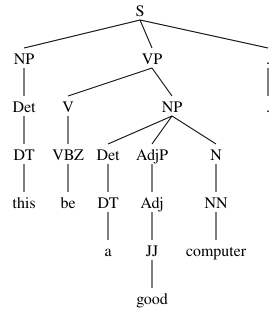

In [104]:
source_tree = translator.analyze_source(preprocessed_english_sentence)
source_tree

### **Transfer Grammar**

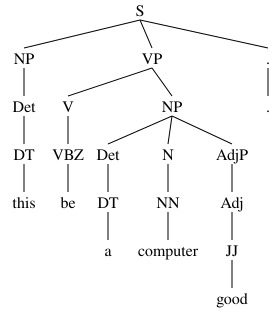

In [105]:
target_structure = translator.transfer_grammar(source_tree)
target_structure

### **Translation**

In [106]:
translation = translator.generate(target_structure)
vietnamese_output = translator._post_process_vietnamese(translation)
vietnamese_output

'Cái này là một máy tính tốt.'